# Support Vector Regression

### Intro
- Vladimir Vapnik

- `Ordinary Least Equation = SUM(y - y_hat)^2` => `min`

- Vertical to axis not perpendicular to line of tube

- E-Insensitive tube, Slack variable Ei and Ei*

- `((1/2)||w||^2) + c* SUM{i=1, m}(Ei + Ei*)` => `min`

### Additional Read:
**Chapter 4**: *Support Vector Regression (from: Efficient Learning Machines: Theories, Concepts, and Applications for Engineers and System Designers)* - By Maritte Awad & Rahul Khanna (2015) - https://core.ac.uk/download/pdf/81523322.pdf


# Hands-on for SVR: 

### Step 1: SVR Model Training: Feature Scaling, Dataset preparation, importing libraries and dataset

In [1]:
# Importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# Importing the dataset
dataset = pd.read_csv("Position_Salaries.csv")
X = dataset.iloc[:,1:-1].values
y = dataset.iloc[:,-1].values

### Step 2: Reshaping Data for SVR - preparing y vector for feature scaling and SVR data preparation - Scaling X & y independently with Standard Scaler

In [6]:
print(X)
print("*************************************************************")
print(y)
print("*************************************************************")

y = y.reshape(len(y),1)

print("**************************************************************")
print(y)
print("**************************************************************")

[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]]
*************************************************************
[  45000   50000   60000   80000  110000  150000  200000  300000  500000
 1000000]
*************************************************************
**************************************************************
[[  45000]
 [  50000]
 [  60000]
 [  80000]
 [ 110000]
 [ 150000]
 [ 200000]
 [ 300000]
 [ 500000]
 [1000000]]
**************************************************************


In [8]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
sc_y = StandardScaler()
X = sc_X.fit_transform(X)
y = sc_y.fit_transform(y)
print("**************************************************************")
print(X)
print("**************************************************************")
print(y)
print("**************************************************************")

**************************************************************
[[-1.5666989 ]
 [-1.21854359]
 [-0.87038828]
 [-0.52223297]
 [-0.17407766]
 [ 0.17407766]
 [ 0.52223297]
 [ 0.87038828]
 [ 1.21854359]
 [ 1.5666989 ]]
**************************************************************
[[-0.72004253]
 [-0.70243757]
 [-0.66722767]
 [-0.59680786]
 [-0.49117815]
 [-0.35033854]
 [-0.17428902]
 [ 0.17781001]
 [ 0.88200808]
 [ 2.64250325]]
**************************************************************


### Step 3: Creating and Training SVR Model with RBF kernel

In [9]:
# Training the SVR model on the whole dataset
from sklearn.svm import SVR
regressor = SVR(kernel="rbf")
regressor.fit(X,y)

C:\Users\LOQ\anaconda3\envs\ml_env\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


##### The Gaussian RBF kernel
$K(x_up_arrow, l_up_arrow_i) = e^((|| x_up_arrow = l_up_arrow_i|| ^ 2)^2/(2 * sigma ^ 2))$

https://data.flair.training/blogs/svm_kernel_funtions/

### Step 4: SVR Model Prediction: Handling Scale DAta and Inverse Transformation

In [12]:
# Predicting a new result
print(regressor.predict(sc_X.transform([[6.5]])))

[-0.27861589]


In [13]:
print(sc_y.inverse_transform(regressor.predict(sc_X.transform([[6.5]])).reshape(-1,1)))

[[170370.0204065]]


### Step 5: Plotting Support Vector Regression Models

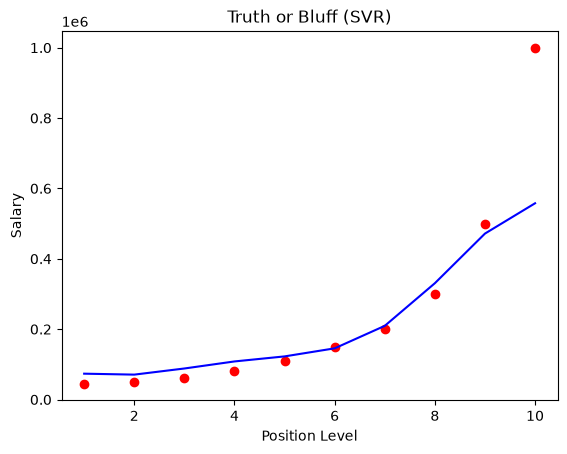

In [14]:
# Visualizing the SVR results
plt.scatter(sc_X.inverse_transform(X), sc_y.inverse_transform(y), color="red")
plt.plot(sc_X.inverse_transform(X), sc_y.inverse_transform(regressor.predict(X).reshape(-1,1)), color="blue")
plt.title("Truth or Bluff (SVR)")
plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.show()

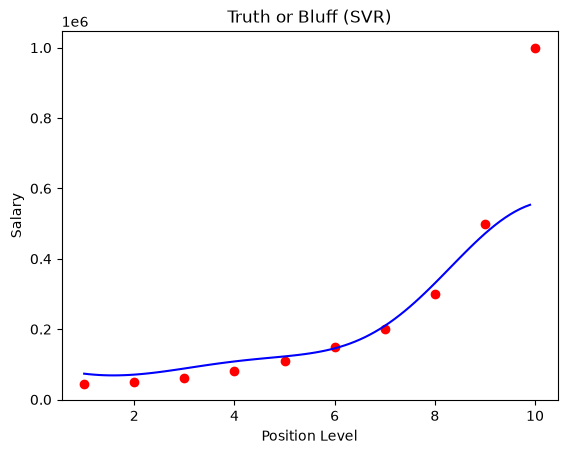

In [16]:
# Visualizing the SVR results (For higher resolution and smoother curve)

X_grid = np.arange(sc_X.inverse_transform(X).min(), sc_X.inverse_transform(X).max(),0.1)
X_grid = X_grid.reshape((len(X_grid),1))

plt.scatter(sc_X.inverse_transform(X), sc_y.inverse_transform(y), color="red")
plt.plot(X_grid, sc_y.inverse_transform(regressor.predict(sc_X.transform(X_grid)).reshape(-1,1)), color="blue")
plt.title("Truth or Bluff (SVR)")
plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.show()